### **CELL 1: IMPORTS AND SETUP**

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
import os

notebook_dir = os.getcwd()

if "analysis" in notebook_dir:
    db_path = os.path.abspath(os.path.join(notebook_dir, "..", "database", "sales.db"))
else:
    db_path = os.path.abspath(os.path.join(notebook_dir, "database", "sales.db"))

db_path = db_path.replace("\\","/")

#connect to the SQLite database
engine = create_engine(f"sqlite:///{db_path}")

#consistent style for every chart
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["font.size"] = 12

#reads a .sql file and returns the contents as a string
def read_sql_file(filepath):
    current_dir = os.getcwd()
    if "analysis" in current_dir:
        full_path = os.path.abspath(
            os.path.join(current_dir, "..", filepath))
    else:
        full_path = os.path.abspath(filepath)
        
    with open(full_path, "r") as f:
        return f.read()

#saves charts to analysis/charts/ folder and displays it
def save_and_show(filename):
    os.makedirs("charts", exist_ok=True)
    plt.savefig(f"charts/{filename}", dpi=150, bbox_inches="tight")
    plt.show()

print("Setup complete - database connected")

Setup complete - database connected


### **CELL 2: KPI SUMMARY**

In [31]:
total_revenue = pd.read_sql(
    "SELECT SUM(revenue) FROM sales_clean", engine).iloc[0,0]

total_orders = pd.read_sql(
    "SELECT COUNT(order_id) FROM sales_clean", engine).iloc[0,0]

total_lost = pd.read_sql(
    "SELECT SUM(lost_revenue) FROM sales_clean", engine).iloc[0,0]

total_days = pd.read_sql(
    "SELECT MAX(day_number) FROM sales_clean", engine).iloc[0,0]

print("E-COMMERCE PIPELINE - 30 DAY KPI SUMMARY")
print(f"Days of data: {int(total_days)}")
print(f"Total orders: {int(total_orders):,}")
print(f"Total revenue earned: Rs.{total_revenue:,.0f}")
print(f"Total revenue lost: Rs.{total_lost:,.0f}")

E-COMMERCE PIPELINE - 30 DAY KPI SUMMARY
Days of data: 30
Total orders: 1,202
Total revenue earned: Rs.5,407,573
Total revenue lost: Rs.1,115,274


### **CELL 3: DATASET OVERVIEW**

In [32]:
df = pd.read_sql("SELECT * FROM sales_clean", engine)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values per column:\n{df.isnull().sum()}")
print(f"\nBasic statistics for numberic columns:")
df[["price", "quantity", "fulfilled", "revenue", "lost_revenue", "stock_remaining"]].describe().round(2)

Dataset shape: 1,202 rows x 18 columns

Column names:
['order_id', 'date', 'day_number', 'product_id', 'product_name', 'category', 'price', 'quantity', 'fulfilled', 'revenue', 'city', 'payment_method', 'customer_name', 'customer_phone', 'stock_remaining', 'lost_sales', 'lost_revenue', 'phone_valid']

Data types:
order_id             str
date                 str
day_number         int64
product_id           str
product_name         str
category             str
price              int64
quantity           int64
fulfilled          int64
revenue            int64
city                 str
payment_method       str
customer_name        str
customer_phone       str
stock_remaining    int64
lost_sales         int64
lost_revenue       int64
phone_valid        int64
dtype: object

Missing values per column:
order_id           0
date               0
day_number         0
product_id         0
product_name       0
category           0
price              0
quantity           0
fulfilled          0
reven

,price,quantity,fulfilled,revenue,lost_revenue,stock_remaining
count,1202.00,1202.00,1202.00,1202.00,1202.00,1202.00
mean,965.47,5.27,4.37,4498.81,927.85,123.24
std,618.68,3.40,3.77,7522.55,3288.62,97.04
min,299.00,2.00,0.00,0.00,0.00,0.00
25%,499.00,3.00,2.00,1396.00,0.00,32.25
50%,709.00,5.00,4.00,2895.00,0.00,118.00
75%,1189.00,7.00,6.00,5593.00,0.00,198.00
max,2199.00,68.00,68.00,149532.00,54975.00,406.00


### **CELL 4: ETL DATA QUALITY REPORT**

In [33]:
total_rows = len(df)

unknown_names = len(df[df["customer_name"] == "Unknown"])
unknown_phones = len(df[df["customer_phone"] == "Unknown"])
unknown_cities = len(df[df["city"] == "Unknown"])

invalid_phones = len(df[df["phone_valid"] == 0])

print("ETL PIPELINE - DATA QUALITY REPORT")
print(f"\nTotal rows processed: {total_rows:,}")
print()
print(f"Missing customer names: {unknown_names}")
print(f"Missing phone numbers: {unknown_phones}")
print(f"Missing city values: {unknown_cities}")
print(f"Invalid phone numbers: {invalid_phones}")

ETL PIPELINE - DATA QUALITY REPORT

Total rows processed: 1,202

Missing customer names: 90
Missing phone numbers: 85
Missing city values: 99
Invalid phone numbers: 127


### **CELL 5: PAYMENT METHOD BREAKDOWN**

Payment Method Breakdown:
payment_method  total_orders  total_revenue  order_share_pct
           UPI           495        2419237            41.18
          Card           339        1627851            28.20
           COD           176         662815            14.64
   Net Banking           133         505425            11.06
        Wallet            59         192245             4.91



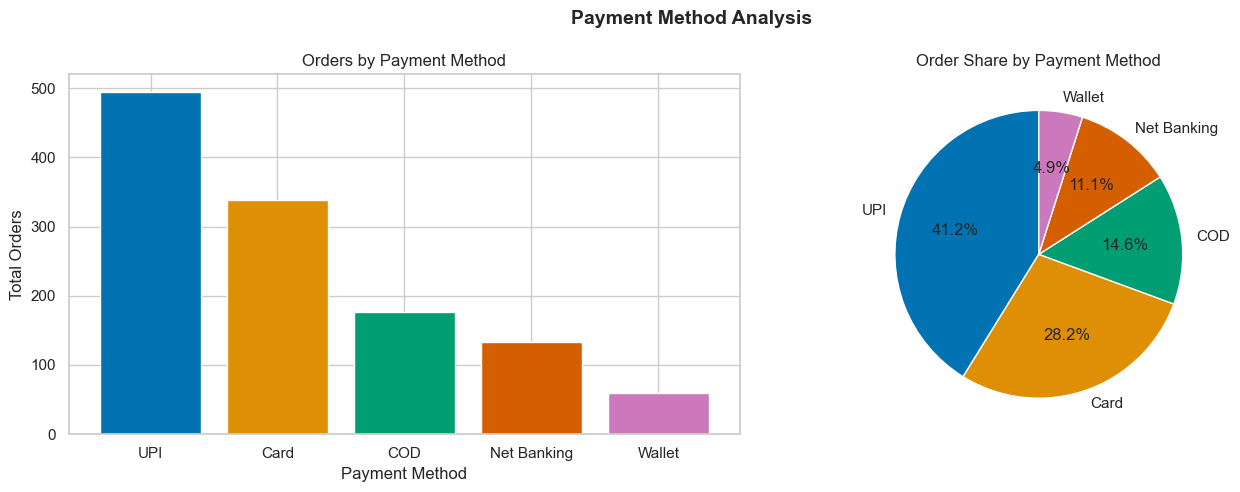

In [34]:
payment = pd.read_sql("""
                      SELECT 
                      payment_method,
                      COUNT(order_id) AS total_orders,
                      SUM(revenue) AS total_revenue,
                      ROUND(COUNT(order_id) * 100.0/
                      SUM(COUNT(order_id)) OVER (), 2) AS order_share_pct
                      FROM sales_clean
                      GROUP BY payment_method
                      ORDER BY total_orders DESC
                      """, engine)

print("Payment Method Breakdown:")
print(payment.to_string(index=False))
print()

fig, axes = plt.subplots(1,2,figsize=(14,5))

my_colors = sns.color_palette("colorblind",5)

#Left - bar chart
axes[0].bar(
    payment["payment_method"],
    payment["total_orders"],
    color = my_colors
)
axes[0].set_title("Orders by Payment Method")
axes[0].set_xlabel("Payment Method")
axes[0].set_ylabel("Total Orders")

#Right - pie chart
axes[1].pie(
    payment["order_share_pct"],
    labels = payment["payment_method"],
    autopct = "%1.1f%%",
    colors = my_colors,
    startangle = 90
)
axes[1].set_title("Order Share by Payment Method")

plt.suptitle("Payment Method Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
save_and_show("payment_methods.png")

**Insight:** Unsurprisingly, UPI dominates at 42% of all transactions, which makes perfect sense for the Indian market right now. It's closely followed by Card transactions which takes up 28%. While Cash on Delivery is still an option people use, the data shows our audience has overwhelmingly shifted to digital-first payments.

### **CELL 6: DAILY REVENUE TREND**

Daily Revenue and Lost Revenue - 30 Days:
 day_number       date  revenue  lost_revenue
          1 2024-03-01   130238             0
          2 2024-03-02   221259             0
          3 2024-03-03   241139             0
          4 2024-03-04   212229             0
          5 2024-03-05   251843             0
          6 2024-03-06   211636             0
          7 2024-03-07   197368             0
          8 2024-03-08   390652             0
          9 2024-03-09   272990             0
         10 2024-03-10   171501         54975
         11 2024-03-11   113142         35184
         12 2024-03-12   173044         10995
         13 2024-03-13   156307         24189
         14 2024-03-14   235730         30786
         15 2024-03-15   225553         23581
         16 2024-03-16   119394         39278
         17 2024-03-17   186978         31782
         18 2024-03-18   176798         66261
         19 2024-03-19   137671         62167
         20 2024-03-20   132807       

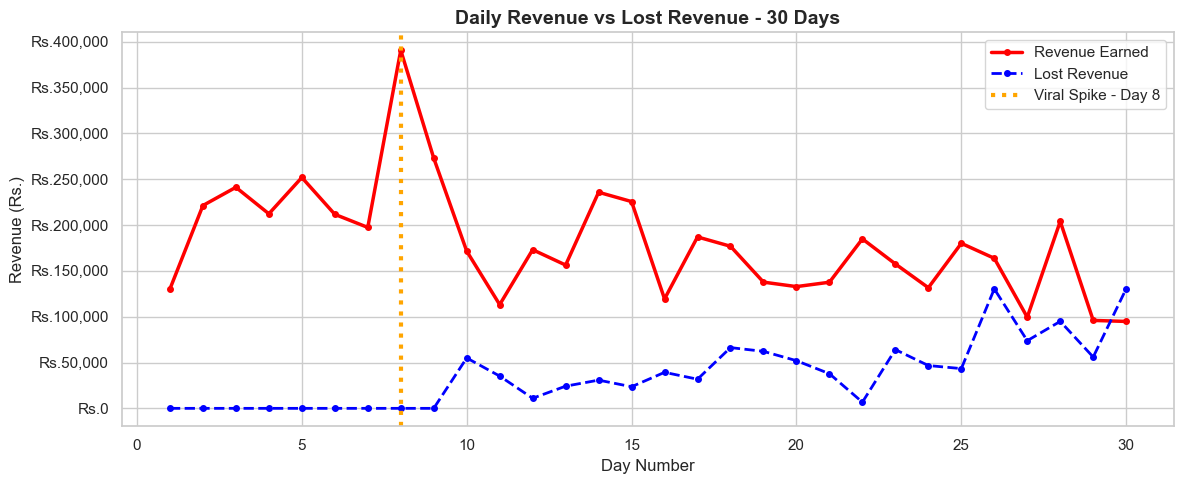

In [35]:
daily = pd.read_sql("""
                    SELECT 
                    day_number,
                    date,
                    SUM(revenue) AS revenue,
                    SUM(lost_revenue) AS lost_revenue
                    FROM sales_clean
                    GROUP BY day_number, date
                    ORDER BY day_number
                    """, engine)

daily["date"] = pd.to_datetime(daily["date"])

print("Daily Revenue and Lost Revenue - 30 Days:")
print(daily.to_string(index=False))
print()

fig, ax = plt.subplots()

ax.plot(
    daily["day_number"], daily["revenue"],
    color = "red", linewidth = 2.5,
    marker = "o", markersize = 4,
    label = "Revenue Earned"
)

ax.plot(
    daily["day_number"], daily["lost_revenue"],
    color = "blue", linewidth = 2,
    linestyle = "--", marker = "o", markersize = 4,
    label = "Lost Revenue"
)

ax.axvline(
    x=8, color="orange",
    linestyle=":", linewidth=3,
    label="Viral Spike - Day 8"
)

ax.set_title("Daily Revenue vs Lost Revenue - 30 Days",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Day Number")
ax.set_ylabel("Revenue (Rs.)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rs.{x:,.0f}"))
ax.legend()
plt.tight_layout()
save_and_show("chart1_daily_revenue.png")

**Insight:** Revenue spiked sharply on Day 8 when Wireless Earbuds went viral. Stock ran out by Day 10, after which actual revenue dropped while lost revenue climbed.

### **CELL 7: REVENUE BY CATEGORY**

Revenue by Category:
   category  total_revenue  total_orders  revenue_pct
Electronics        2980696           304    55.120772
     Beauty         978614           288    18.097102
    Fitness         785306           305    14.522337
     Health         662957           305    12.259788



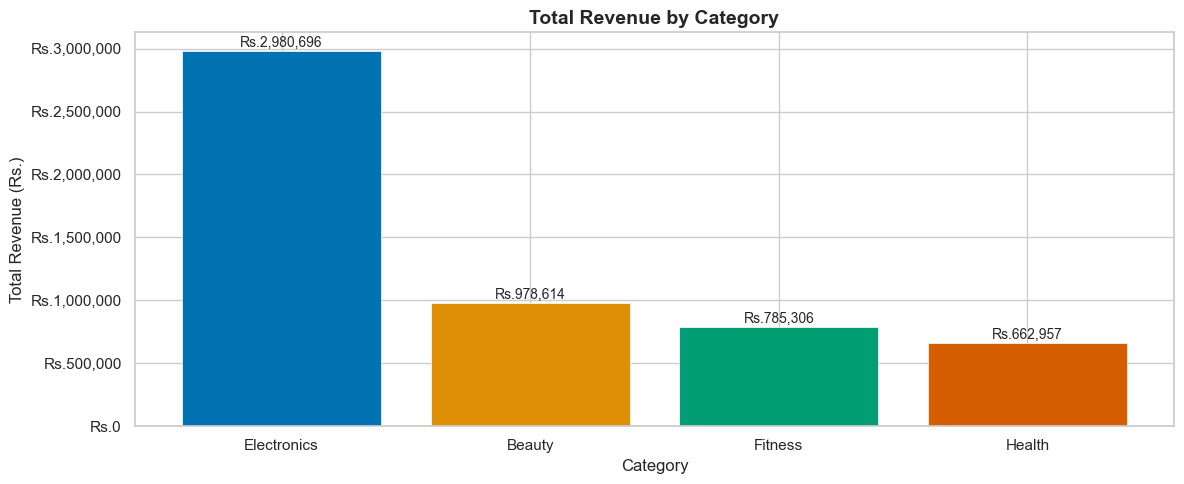

In [38]:
category_df = pd.read_sql(
    read_sql_file("queries/revenue_by_category.sql"), engine)

category_df["revenue_pct"] = (category_df["total_revenue"] / category_df["total_revenue"].sum()) * 100
print("Revenue by Category:")
print(category_df.to_string(index=False))
print()

fig, ax = plt.subplots()

bars = ax.bar(
    category_df["category"],
    category_df["total_revenue"],
    color = my_colors,
    edgecolor = "white", linewidth = 0.5
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 8000,
        f"Rs.{height:,.0f}",
        ha = "center", va = "bottom", fontsize = 10
    )

ax.set_title("Total Revenue by Category", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Category")
ax.set_ylabel("Total Revenue (Rs.)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rs.{x:,.0f}"))
plt.tight_layout()
save_and_show("chart2_revenue_by_category.png")


**Insight:** Electronics dominates with over 55% of total revenue.Beauty and Fitness are strong secondary categories worth expanding inventory for.